# Sustainable Capitol Hill 2024 Q3 Meeting

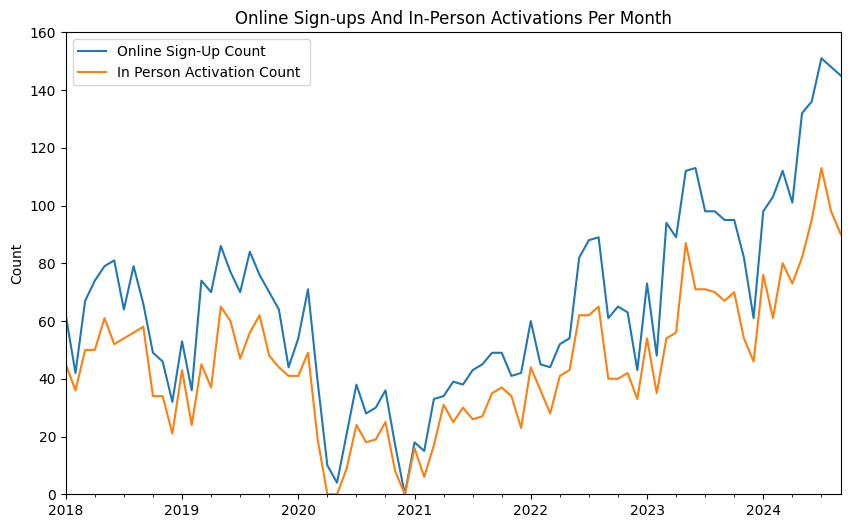

In [3]:
import numpy as np
import pandas as pd

members = pd.read_pickle('~/chtl/data/processed/users.pkl')

def to_month(timestamp_series):
    return timestamp_series.apply(lambda t: pd.Timestamp(t.year, t.month, 1))

member_dates = pd.DataFrame(
    {
        'Online Sign-Up Count': members['Created'].groupby(to_month(members['Created'])).size().asfreq('MS',fill_value=0),
        'In Person Activation Count ': members['First Membership Started'].groupby(to_month(members['First Membership Started'])).size().asfreq('MS',fill_value=0)
    },
    index=pd.date_range(freq='MS', start=pd.Timestamp('2018-01-01'), end=pd.Timestamp('2024-09-15'))
)

graph = member_dates.plot(
    title='Online Sign-ups And In-Person Activations Per Month',
    figsize=(10, 6),
    ylabel='Count',
    ylim=(0,160),
)

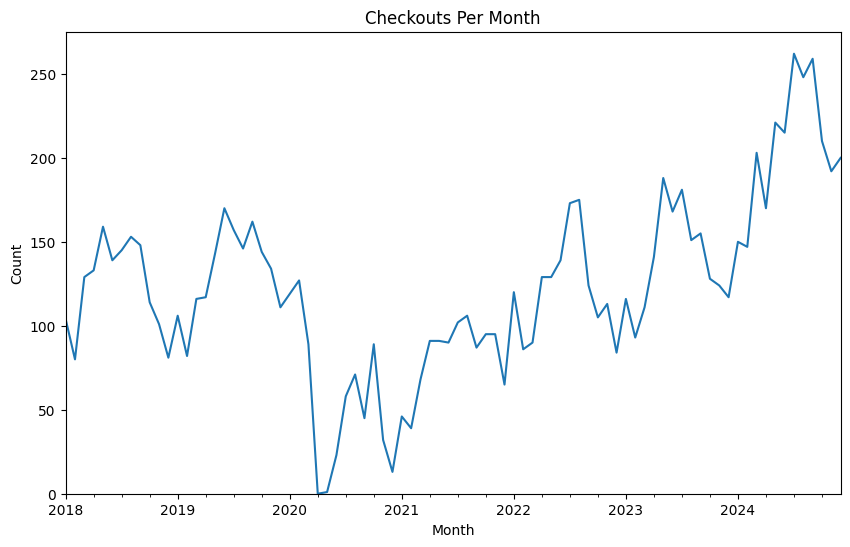

In [5]:
import pandas as pd
from datetime import date

checkouts = pd.read_pickle('~/chtl/data/processed/checkouts.pkl')
checkouts['Month'] = pd.to_datetime(checkouts['Checked Out'].map(lambda c: date(c.year, c.month, 1)))
checkouts['Year'] = checkouts['Checked Out'].map(lambda c: c.year)
# Exclude 2015 (tool library not fully open) and current year if it is only a month or two in.
recent_years = checkouts[checkouts['Year'].isin([2018, 2019, 2020, 2021, 2022, 2023, 2024])]
by_month = recent_years.groupby('Month').size().asfreq('MS', fill_value=0)

# Save to a variable so the __str__ doesn't get displayed
graph = by_month.plot(figsize=(10, 6), title='Checkouts Per Month', ylabel='Count', ylim=0)

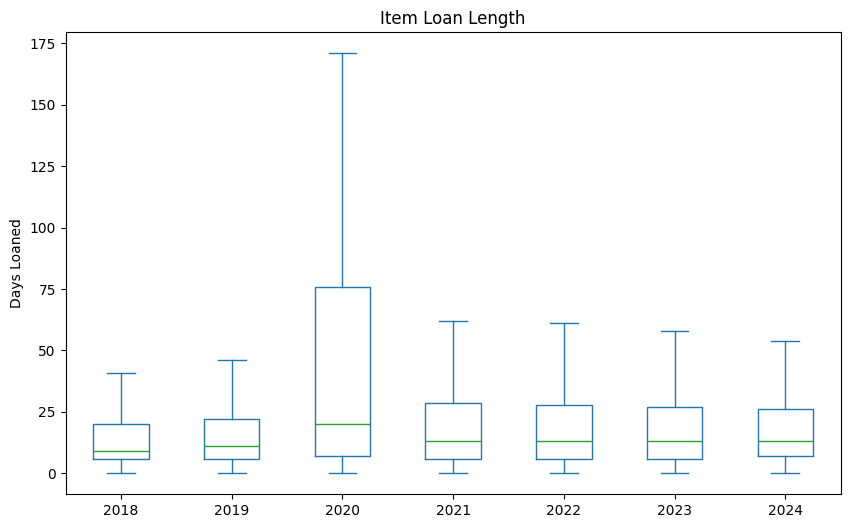

In [9]:
from datetime import date
import pandas as pd

loans = pd.read_pickle('~/chtl/data/processed/loans.pkl')
loans['Length'] = loans['Checked In'].fillna(pd.to_datetime(date.today())) - loans['Checked Out']
# Grouping by the "Year" it was checked out artificially reduces the most recent years loan length.
# Previous years get all unreturned items counted for the whole year. In the current year there isn't
# enough time for those to add up yet.
loans['Year'] = loans['Checked Out'].map(lambda c: c.year)
recent_years = loans[loans['Year'].isin([2018, 2019, 2020, 2021, 2022, 2023, 2024])]

by_year = pd.DataFrame({'Days': recent_years['Length'].map(lambda l: l.days), 'Year': recent_years['Year']})
graph = by_year.pivot(columns='Year', values='Days').plot.box(
    # "fliers" in plt parlance are outliers.  We don't show them here because there are so many, they make the
    # rest of the plot much harder to read.  The gist is that a few loans are just never returned.
    showfliers=False,
    figsize=(10, 6),
    title='Item Loan Length',
    ylabel='Days Loaned',
)

## Member Stories

These are some of the projects I've heard people mention during my shifts:

> I am refinishing my industrial loft

> I added a hole to my belt loop while I was in the back

> I just moved to Seattle, and want to hang a shelf but don't have any tools.

> Someone just broke up with me 5 minute ago and I need to agressively cut wood

> I'd like to shorten this bit of metal shelving.

> I'm demolishing my kitchen.

## Income

### \\$10k revenue - \\$5k expenses = \\$5k net income

## Revenue

The Capitol Hill Tool Library gets revenue from in-person donations, donations directly to Sustainable Capitol Hill via corporate giving platforms, and interest on our reserves. CHTL stopped charging late fees midway through 2024.

### In-Person Donations

In 2024, we received \\$7,350 in credit card membership donations, another \\$2k in cash donations. These are mostly membership donations, but occasionally include one-off donations and people voluntarily donating after returning late items. The average in-person donation is about \\$10, lower than it's been in previous years

### Corporate Giving Platforms

CHTL has a Benevity account set up to receive direct donations from employees of large corporations like Microsoft and Google.  We received an additional ~$2,330 in these direct donations. 

### Interest

We've earned \\$327 in interest so far in 2024.

### Expenses

Our primary expenses are money spent on tools (\~$1.5k), insurance (\~2k), and rent (\~1.5k).

#### About This Report
Code and instructions for playing with the Capitol Hill Tool Library data yourself are available at https://github.com/mshenfield/chtl-data-pipeline. Ask [Max Shenfield](https://app.slack.com/client/TAAD5LKJ4/D02BHR5J7J6/user_profile/U02BB35KMRU) for access.  The project is built using [Python](https://python.org), [Pandas](https://pandas.pydata.org/), and [Jupyter Notebook](https://jupyter.org/).